In [28]:
import pandas as pd

In [29]:
df = pd.read_csv("Dataset cleaningggg.csv")

print(df.head())

          order_id  order_date   ship_date       ship_mode    customer_name  \
0     AG-2011-2040  01-01-2011  01-06-2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883  01-01-2011  01-08-2011  Standard Class      Joseph Holt   
2     HU-2011-1220  01-01-2011  01-05-2011    Second Class    Annie Thurman   
3  IT-2011-3647632  01-01-2011  01-05-2011    Second Class     Eugene Moren   
4    IN-2011-47883  01-01-2011  01-08-2011  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Canada   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name  sales  quantity  \
0  Office Supplies      Storage    

In [30]:
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

(51325, 21)
Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='str')
order_id              str
order_date            str
ship_date             str
ship_mode             str
customer_name         str
segment               str
state                 str
country               str
market                str
region                str
product_id            str
category              str
sub_category          str
product_name          str
sales             float64
quantity          float64
discount          float64
profit            float64
shipping_cost     float64
order_priority        str
year              float64
dtype: object
order_id          54
order_date        54
ship_date         54
ship_mode         54
customer_name     54
segment    

In [31]:
print("Shape:", df.shape)

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- DUPLICATES ---")
print("Duplicate rows:", df.duplicated().sum())

print("\n--- DATA TYPES ---")
print(df.dtypes)

print("\n--- UNIQUE VALUES ---")
print(df.nunique())

Shape: (51325, 21)

--- MISSING VALUES ---
order_id          54
order_date        54
ship_date         54
ship_mode         54
customer_name     54
segment           54
state             54
country           54
market            54
region            54
product_id        54
category          54
sub_category      54
product_name      54
sales             54
quantity          54
discount          54
profit            54
shipping_cost     54
order_priority    54
year              54
dtype: int64

--- DUPLICATES ---
Duplicate rows: 53

--- DATA TYPES ---
order_id              str
order_date            str
ship_date             str
ship_mode             str
customer_name         str
segment               str
state                 str
country               str
market                str
region                str
product_id            str
category              str
sub_category          str
product_name          str
sales             float64
quantity          float64
discount          float64
pr

In [32]:
# =========================
# 1. LOAD DATA
# =========================


print("Original Shape:", df.shape)


# =========================
# 2. REMOVE EXACT DUPLICATES
# =========================

print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())


# =========================
# 3. CLEAN TEXT COLUMNS
# =========================

text_columns = df.select_dtypes(include='object').columns

for col in text_columns:
    df[col] = df[col].str.strip()


# =========================
# 4. CONVERT DATE COLUMNS
# =========================

df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='%d-%m-%Y',
    errors='coerce'
)

df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    format='%d-%m-%Y',
    errors='coerce'
)


# =========================
# 5. CHECK MISSING VALUES
# =========================

print("\nMissing Values:")
print(df.isnull().sum())


# =========================
# 6. CHECK DATA TYPES
# =========================

print("\nData Types:")
print(df.dtypes)


# =========================
# 7. CHECK NUMERICAL DATA
# =========================

numeric_columns = [
    'sales',
    'quantity',
    'discount',
    'profit',
    'shipping_cost',
    'year'
]

print("\nNumerical Summary:")
print(df[numeric_columns].describe())


# =========================
# 8. FINAL DUPLICATE CHECK
# =========================

print("\nFinal Duplicates:", df.duplicated().sum())


# =========================
# 9. FINAL SHAPE
# =========================

print("\nFinal Shape:", df.shape)

Original Shape: (51325, 21)
Duplicates before: 53
Duplicates after: 0

Missing Values:
order_id          1
order_date        1
ship_date         1
ship_mode         1
customer_name     1
segment           1
state             1
country           1
market            1
region            1
product_id        1
category          1
sub_category      1
product_name      1
sales             1
quantity          1
discount          1
profit            1
shipping_cost     1
order_priority    1
year              1
dtype: int64

Data Types:
order_id                     str
order_date        datetime64[us]
ship_date         datetime64[us]
ship_mode                    str
customer_name                str
segment                      str
state                        str
country                      str
market                       str
region                       str
product_id                   str
category                     str
sub_category                 str
product_name                 str
sales

C:\Users\anshu\AppData\Local\Temp\ipykernel_22384\37187078.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include='object').columns



Final Duplicates: 0

Final Shape: (51272, 21)


In [33]:
print(df[df.isnull().all(axis=1)])

      order_id order_date ship_date ship_mode customer_name segment state  \
51271      NaN        NaT       NaT       NaN           NaN     NaN   NaN   

      country market region  ... category sub_category product_name sales  \
51271     NaN    NaN    NaN  ...      NaN          NaN          NaN   NaN   

       quantity  discount  profit  shipping_cost  order_priority year  
51271       NaN       NaN     NaN            NaN             NaN  NaN  

[1 rows x 21 columns]


In [34]:
df = df.dropna(how='all')

In [35]:
print(df.isnull().sum())

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64


In [36]:
print(df.shape)

(51271, 21)


In [37]:
print(df[df.isnull().all(axis=1)])

Empty DataFrame
Columns: [order_id, order_date, ship_date, ship_mode, customer_name, segment, state, country, market, region, product_id, category, sub_category, product_name, sales, quantity, discount, profit, shipping_cost, order_priority, year]
Index: []

[0 rows x 21 columns]


In [38]:
print(df[df.isnull().any(axis=1)])

Empty DataFrame
Columns: [order_id, order_date, ship_date, ship_mode, customer_name, segment, state, country, market, region, product_id, category, sub_category, product_name, sales, quantity, discount, profit, shipping_cost, order_priority, year]
Index: []

[0 rows x 21 columns]


In [39]:
print(df.shape)

(51271, 21)


In [40]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicates:", df.duplicated().sum())
print("\nMissing Values:")
print(df.isnull().sum())

Rows: 51271
Columns: 21


Duplicates: 0

Missing Values:
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64


In [41]:
print(df[['sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'year']].describe())

              sales      quantity      discount        profit  shipping_cost  \
count  51271.000000  51271.000000  51271.000000  51271.000000   51271.000000   
mean     246.439937      3.476468      0.142920     28.622372      26.365625   
std      487.566360      2.278474      0.212283    174.439971      57.287201   
min        0.000000      1.000000      0.000000  -6599.978000       0.000000   
25%       31.000000      2.000000      0.000000      0.000000       2.610000   
50%       85.000000      3.000000      0.000000      9.240000       7.790000   
75%      251.000000      5.000000      0.200000     36.776100      24.445000   
max    22638.000000     14.000000      0.850000   8399.976000     933.570000   

               year  
count  51271.000000  
mean    2012.776794  
std        1.098944  
min     2011.000000  
25%     2012.000000  
50%     2013.000000  
75%     2014.000000  
max     2014.000000  


In [42]:
print("Sales = 0:", (df['sales'] == 0).sum())

Sales = 0: 1


In [43]:
print(df[df['sales'] == 0])

             order_id order_date  ship_date       ship_mode     customer_name  \
40012  US-2014-102288 2014-06-20 2014-06-24  Standard Class  Zuschuss Carroll   

        segment  state        country market   region  ...         category  \
40012  Consumer  Texas  United States     US  Central  ...  Office Supplies   

      sub_category                                       product_name sales  \
40012   Appliances  Hoover Replacement Belt for Commercial Guardsm...   0.0   

       quantity  discount  profit  shipping_cost  order_priority    year  
40012       1.0       0.8   -1.11           0.01          Medium  2014.0  

[1 rows x 21 columns]


In [44]:
print("Sales <= 0:", (df['sales'] <= 0).sum())
print("Quantity <= 0:", (df['quantity'] <= 0).sum())
print("Discount < 0:", (df['discount'] < 0).sum())
print("Discount > 1:", (df['discount'] > 1).sum())
print("Year < 2011:", (df['year'] < 2011).sum())
print("Year > 2014:", (df['year'] > 2014).sum())

Sales <= 0: 1
Quantity <= 0: 0
Discount < 0: 0
Discount > 1: 0
Year < 2011: 0
Year > 2014: 0


In [45]:
for col in ['ship_mode', 'segment', 'category', 'sub_category',
            'market', 'region', 'order_priority']:

    print("\n---", col, "---")
    print(df[col].value_counts())


--- ship_mode ---
ship_mode
Standard Class    30764
Second Class      10304
First Class        7504
Same Day           2699
Name: count, dtype: int64

--- segment ---
segment
Consumer       26508
Corporate      15423
Home Office     9340
Name: count, dtype: int64

--- category ---
category
Office Supplies    31267
Technology         10137
Furniture           9867
Name: count, dtype: int64

--- sub_category ---
sub_category
Binders        6151
Storage        5058
Art            4882
Paper          3537
Chairs         3432
Phones         3356
Furnishings    3166
Accessories    3074
Labels         2606
Envelopes      2434
Supplies       2425
Fasteners      2419
Bookcases      2409
Copiers        2221
Appliances     1755
Machines       1486
Tables          860
Name: count, dtype: int64

--- market ---
market
APAC      10997
LATAM     10291
EU         9998
US         9990
EMEA       5026
Africa     4584
Canada      385
Name: count, dtype: int64

--- region ---
region
Central           1111

In [46]:
columns_to_check = [
    'ship_mode',
    'segment',
    'state',
    'country',
    'market',
    'region',
    'category',
    'sub_category',
    'order_priority'
]

for col in columns_to_check:
    print(f"\n--- {col} ---")
    print(df[col].unique())


--- ship_mode ---
<StringArray>
['Standard Class', 'Second Class', 'Same Day', 'First Class']
Length: 4, dtype: str

--- segment ---
<StringArray>
['Consumer', 'Home Office', 'Corporate']
Length: 3, dtype: str

--- state ---
<StringArray>
[      'Constantine',   'New South Wales',          'Budapest',
         'Stockholm',           'Ontario',          'Auckland',
            'Ninawa',  'National Capital',           'England',
           'Sarawak',
 ...
          'La Rioja',           'Isparta',            'Ruvuma',
         'Kastamonu',          'Paysandú', 'South Chungcheong',
           'Setúbal',           'Karaman',           'Sikasso',
  'Atsimo-Andrefana']
Length: 1094, dtype: str

--- country ---
<StringArray>
[          'Algeria',         'Australia',           'Hungary',
            'Sweden',            'Canada',       'New Zealand',
              'Iraq',       'Philippines',    'United Kingdom',
          'Malaysia',
 ...
             'Nepal',        'Mauritania',        'G

In [47]:
# Standardize text values
text_columns = [
    'ship_mode',
    'segment',
    'state',
    'country',
    'market',
    'region',
    'category',
    'sub_category',
    'order_priority'
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)

In [48]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicates:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

print("Invalid quantity:", (df['quantity'] <= 0).sum())
print("Invalid discount:", ((df['discount'] < 0) | (df['discount'] > 1)).sum())
print("Invalid year:", ((df['year'] < 2011) | (df['year'] > 2014)).sum())

print("Date type:", df['order_date'].dtype)
print("Ship date type:", df['ship_date'].dtype)

Rows: 51271
Columns: 21
Duplicates: 0
Missing values: 0
Invalid quantity: 0
Invalid discount: 0
Invalid year: 0
Date type: datetime64[us]
Ship date type: datetime64[us]


In [49]:
df.to_csv("superstore_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [50]:

# ==========================================
# TASK 2 — DATA ANALYSIS
# ==========================================

# 1. Calculate Total Sales
total_sales = df['sales'].sum()
print("1. Total Sales:", total_sales)


# 2. Calculate Total Profit
total_profit = df['profit'].sum()
print("2. Total Profit:", total_profit)


# 3. Find Average Discount
average_discount = df['discount'].mean()
print("3. Average Discount:", average_discount)


# 4. Find Top 5 Products by Sales
top_5_products = (
    df.groupby('product_name')['sales']
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

print("\n4. Top 5 Products by Sales:")
print(top_5_products)


# 5. Find Top 5 Loss-Making Products
top_5_loss_products = (
    df.groupby('product_name')['profit']
      .sum()
      .sort_values(ascending=True)
      .head(5)
)

print("\n5. Top 5 Loss-Making Products:")
print(top_5_loss_products)


# 6. Analyze Region-wise Sales
region_sales = (
    df.groupby('region')['sales']
      .sum()
      .sort_values(ascending=False)
)

print("\n6. Region-wise Sales:")
print(region_sales)

1. Total Sales: 12635222.0
2. Total Profit: 1467497.61454
3. Average Discount: 0.14292009127967076

4. Top 5 Products by Sales:
product_name
Apple Smart Phone, Full Size             86936.0
Cisco Smart Phone, Full Size             76441.0
Motorola Smart Phone, Full Size          73159.0
Nokia Smart Phone, Full Size             71904.0
Canon imageCLASS 2200 Advanced Copier    61600.0
Name: sales, dtype: float64

5. Top 5 Loss-Making Products:
product_name
Cubify CubeX 3D Printer Double Head Print   -8879.9704
Lexmark MX611dhe Monochrome Laser Printer   -4589.9730
Motorola Smart Phone, Cordless              -4447.0380
Cubify CubeX 3D Printer Triple Head Print   -3839.9904
Bevis Round Table, Adjustable Height        -3649.8940
Name: profit, dtype: float64

6. Region-wise Sales:
region
Central           2821740.0
South             1600600.0
North             1248121.0
Oceania           1098253.0
Southeast Asia     883702.0
North Asia         846991.0
EMEA               805053.0
Africa     

In [51]:
import matplotlib.pyplot as plt
import os


1. Sales by Region
                    sales
region                   
Central         2821740.0
South           1600600.0
North           1248121.0
Oceania         1098253.0
Southeast Asia   883702.0
North Asia       846991.0
EMEA             805053.0
Africa           783345.0
Central Asia     752839.0
West             725514.0
East             678548.0
Caribbean        323584.0
Canada            66932.0


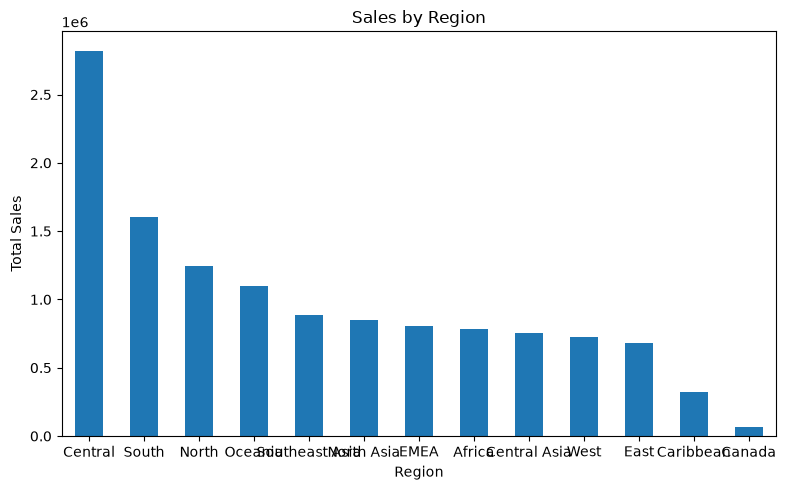


2. Profit by Category
                       profit
category                     
Technology       663200.14804
Office Supplies  518172.58390
Furniture        286124.88260


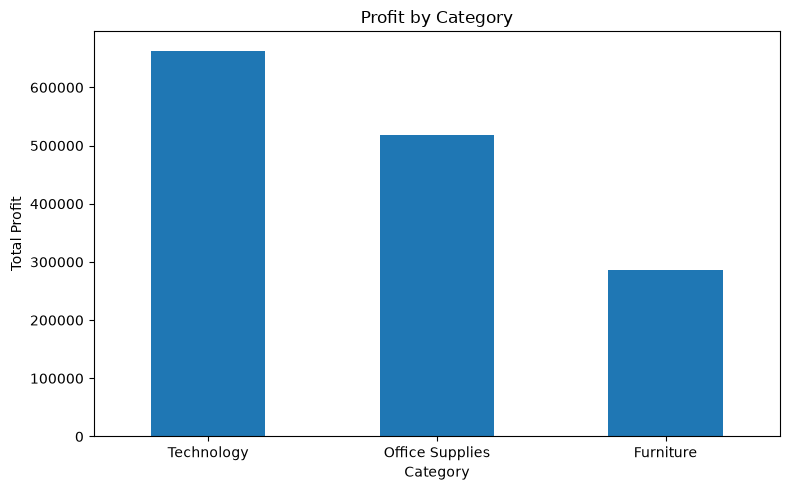


3. Segment-wise Sales
                 sales
segment               
Consumer     6503476.0
Corporate    3822954.0
Home Office  2308792.0


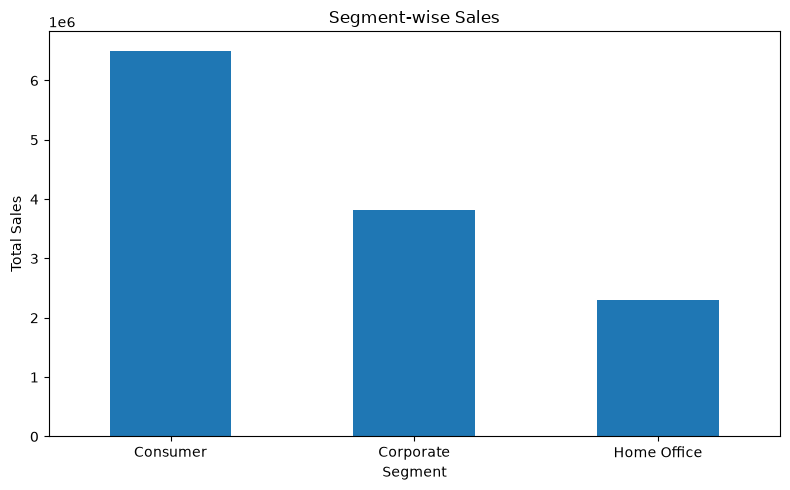


4. Monthly Sales Trend
            sales
month            
2011-01  138245.0
2011-02  134969.0
2011-03  171445.0
2011-04  128901.0
2011-05  148158.0
2011-06  189339.0
2011-07  162039.0
2011-08  219236.0
2011-09  255250.0
2011-10  204679.0
2011-11  214931.0
2011-12  292377.0
2012-01  162807.0
2012-02  152663.0
2012-03  201626.0
2012-04  187470.0
2012-05  218953.0
2012-06  249284.0
2012-07  174403.0
2012-08  271675.0
2012-09  256578.0
2012-10  239324.0
2012-11  270725.0
2012-12  291971.0
2013-01  205093.0
2013-02  190845.0
2013-03  230551.0
2013-04  233188.0
2013-05  304523.0
2013-06  341161.0
2013-07  223649.0
2013-08  323889.0
2013-09  326904.0
2013-10  270131.0
2013-11  383051.0
2013-12  371269.0
2014-01  268275.0
2014-02  244179.0
2014-03  347703.0
2014-04  302140.0
2014-05  304795.0
2014-06  372608.0
2014-07  278670.0
2014-08  432742.0
2014-09  400124.0
2014-10  406676.0
2014-11  508985.0
2014-12  427023.0


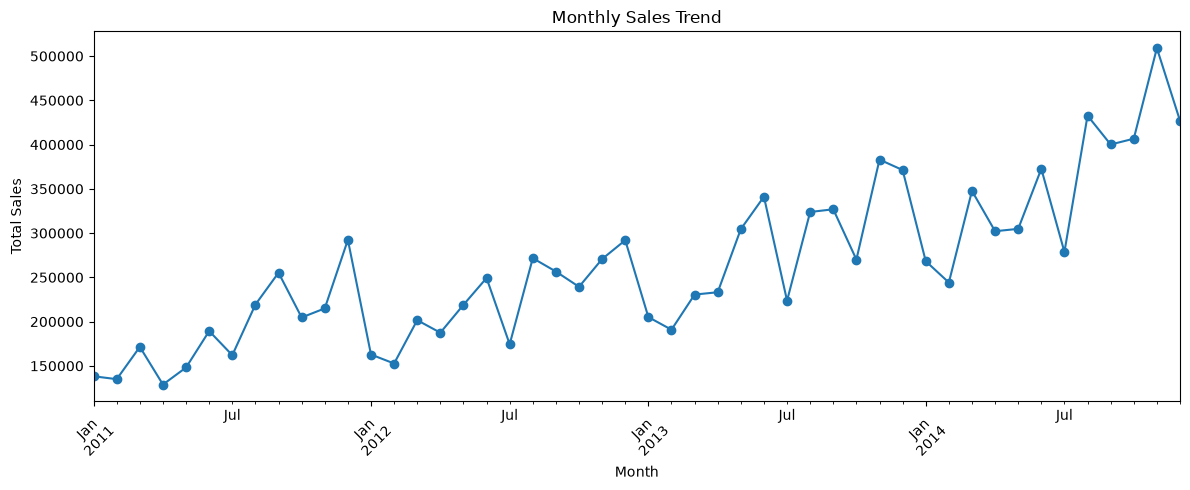


✅ All charts saved successfully in the 'charts' folder!


In [52]:
# ==========================================
# TASK 3 — PIVOT TABLE & CHARTS
# SAVE CHARTS AS PNG
# ==========================================

# Create charts folder automatically
os.makedirs("charts", exist_ok=True)


# ==========================================
# 1. SALES BY REGION
# ==========================================

sales_by_region = pd.pivot_table(
    df,
    values='sales',
    index='region',
    aggfunc='sum'
).sort_values('sales', ascending=False)

print("1. Sales by Region")
print(sales_by_region)

sales_by_region.plot(
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()

# Save PNG
plt.savefig("charts/sales_by_region.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


# ==========================================
# 2. PROFIT BY CATEGORY
# ==========================================

profit_by_category = pd.pivot_table(
    df,
    values='profit',
    index='category',
    aggfunc='sum'
).sort_values('profit', ascending=False)

print("\n2. Profit by Category")
print(profit_by_category)

profit_by_category.plot(
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()

# Save PNG
plt.savefig("charts/profit_by_category.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


# ==========================================
# 3. SEGMENT-WISE SALES
# ==========================================

segment_sales = pd.pivot_table(
    df,
    values='sales',
    index='segment',
    aggfunc='sum'
).sort_values('sales', ascending=False)

print("\n3. Segment-wise Sales")
print(segment_sales)

segment_sales.plot(
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Segment-wise Sales')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()

# Save PNG
plt.savefig("charts/segment_wise_sales.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


# ==========================================
# 4. MONTHLY SALES TREND
# ==========================================

df['order_date'] = pd.to_datetime(df['order_date'])

df['month'] = df['order_date'].dt.to_period('M')

monthly_sales = pd.pivot_table(
    df,
    values='sales',
    index='month',
    aggfunc='sum'
)

print("\n4. Monthly Sales Trend")
print(monthly_sales)

monthly_sales.plot(
    kind='line',
    figsize=(12, 5),
    legend=False,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

# Save PNG
plt.savefig("charts/monthly_sales_trend.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


print("\n✅ All charts saved successfully in the 'charts' folder!")